# Reproduce Manuscript Figures

This notebook reproduces the three main figures for *Hypsographic Demography: Age and Change in Population by Altitude* from Dataset S1. It does not run the full gridded extraction workflow and does not generate exploratory figures.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from PIL import Image
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / 'data' / 'dataset_s1_hypsographic_demography.csv').exists():
    ROOT = Path('/Users/f6z/Documents/projects/montana_state/hypsographic_demography')

DATA = ROOT / 'data'
OUT = ROOT / 'outputs'
FIG = OUT / 'figures'
TAB = OUT / 'tables'
for d in [FIG, TAB]:
    d.mkdir(parents=True, exist_ok=True)

ELEVATION_ORDER = ['<100 m', '100-499 m', '500-1499 m', '1500-2499 m', '2500-3499 m', '>=3500 m']
SETTLEMENT_ORDER = ['Low-density rural', 'Rural cluster', 'Peri-urban', 'Semi-dense urban', 'Dense urban', 'Urban centre']
ELEVATION_LABELS = {'<100 m': '<100 m', '100-499 m': '100–499 m', '500-1499 m': '500–1,499 m', '1500-2499 m': '1,500–2,499 m', '2500-3499 m': '2,500–3,499 m', '>=3500 m': '≥3,500 m'}
AGE_COLORS = {'0-14': '#3B9AB2', '15-64': '#E1AF00', '65+': '#F21A00'}
PNAS_FULL_WIDTH_IN = 17.8 / 2.54
GROWTH_COLOR_LIMIT = 25

available_fonts = {f.name for f in font_manager.fontManager.ttflist}
if 'Helvetica' in available_fonts:
    FIGURE_FONT = 'Helvetica'
elif 'Arial' in available_fonts:
    FIGURE_FONT = 'Arial'
else:
    FIGURE_FONT = 'DejaVu Sans'

mpl.rcParams.update({
    'font.family': FIGURE_FONT,
    'font.size': 6.6,
    'axes.titlesize': 7.4,
    'axes.labelsize': 6.8,
    'xtick.labelsize': 6.0,
    'ytick.labelsize': 6.0,
    'legend.fontsize': 6.0,
    'axes.linewidth': 0.55,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'savefig.facecolor': 'white',
})

def pct(x, digits=1):
    return f'{100 * x:.{digits}f}%'

def bill(x, digits=2):
    return f'{x / 1e9:.{digits}f} billion'

def mill(x, digits=1):
    return f'{x / 1e6:.{digits}f} million'

def savefig(name, fig):
    for ext in ['png', 'pdf']:
        path = FIG / f'{name}.{ext}'
        fig.savefig(path, dpi=600 if ext == 'png' else None, bbox_inches='tight', facecolor='white')
        if ext == 'png':
            img = Image.open(path)
            if img.mode != 'RGB':
                img.convert('RGB').save(path)

def style_axes(ax, grid_axis='x'):
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_linewidth(0.55)
        spine.set_color('0.25')
    if grid_axis:
        ax.grid(axis=grid_axis, color='0.90', linewidth=0.45)
        ax.set_axisbelow(True)

def panel_label(ax, label):
    ax.text(
        0.5,
        1.115,
        label,
        transform=ax.transAxes,
        fontweight='bold',
        va='bottom',
        ha='center',
        fontsize=8.8,
    )

print('Repo root:', ROOT)
print('Figure font:', FIGURE_FONT)


Repo root: /Users/f6z/Documents/projects/montana_state/hypsographic_demography
Figure font: Helvetica


## Read Dataset S1

In [2]:
s1 = pd.read_csv(DATA / 'dataset_s1_hypsographic_demography.csv')
print(f'Dataset S1 rows: {len(s1):,}')
print('Column definitions are documented in data/README.md.')


Dataset S1 rows: 504
Column definitions are documented in data/README.md.


## Rebuild Figure Tables

In [3]:
# Figure 1 table.
f1 = s1[s1['table_name'].eq('figure1_elevation_summary')].copy()
fig1_rows = []
for elev in ELEVATION_ORDER:
    sub = f1[f1['elevation_group'].eq(elev)]
    row = {'elevation_group': elev}
    row['population_total_start'] = sub[(sub['metric'].eq('population')) & (sub['year'].eq(2015))]['value'].sum()
    row['population_total'] = sub[(sub['metric'].eq('population')) & (sub['year'].eq(2025)) & (sub['age_group'].isna())]['value'].sum()
    row['absolute_change'] = row['population_total'] - row['population_total_start']
    row['growth_2015_2025_percent'] = sub[sub['metric'].eq('population_growth')]['value'].sum()
    for age in ['0-14', '15-64', '65+']:
        age_sub = sub[sub['age_group'].eq(age)]
        row[f'{age}_population'] = age_sub[age_sub['metric'].eq('population')]['value'].sum()
        row[f'{age}_share_percent'] = age_sub[age_sub['metric'].eq('population_share')]['value'].sum()
    row['population_2015_billions'] = row['population_total_start'] / 1e9
    row['population_2025_billions'] = row['population_total'] / 1e9
    row['youth_population'] = row['0-14_population']
    row['working_age_population'] = row['15-64_population']
    row['old_age_population'] = row['65+_population']
    row['youth_share_percent'] = row['0-14_share_percent']
    row['working_age_share_percent'] = row['15-64_share_percent']
    row['old_age_share_percent'] = row['65+_share_percent']
    fig1_rows.append(row)
main_fig01_data = pd.DataFrame(fig1_rows)
global_pop_2025 = main_fig01_data['population_total'].sum()

main_fig01_data.to_csv(TAB / 'main_fig01_data.csv', index=False)

# Figure 1C age-contribution table.
f1c = s1[s1['table_name'].eq('figure1_age_contribution')].copy()
fig1c_rows = []
for elev in ELEVATION_ORDER:
    sub = f1c[f1c['elevation_group'].eq(elev)]
    denominator = sub[(sub['metric'].eq('population_denominator')) & (sub['year'].eq(2015))]['value'].sum()
    total_growth = sub[(sub['metric'].eq('population_growth')) & (sub['interval'].eq('2015-2025'))]['value'].sum()
    for age in ['0-14', '15-64', '65+']:
        age_sub = sub[sub['age_group'].eq(age)]
        pop_2015 = age_sub[(age_sub['metric'].eq('population')) & (age_sub['year'].eq(2015))]['value'].sum()
        pop_2025 = age_sub[(age_sub['metric'].eq('population')) & (age_sub['year'].eq(2025))]['value'].sum()
        absolute_change = age_sub[(age_sub['metric'].eq('absolute_change')) & (age_sub['interval'].eq('2015-2025'))]['value'].sum()
        contribution = age_sub[(age_sub['metric'].eq('contribution_to_total_growth')) & (age_sub['interval'].eq('2015-2025'))]['value'].sum()
        fig1c_rows.append({
            'elevation_group': elev,
            'age_group': age,
            'population_2015_ageclass': pop_2015,
            'population_2025_ageclass': pop_2025,
            'absolute_change_ageclass': absolute_change,
            'population_2015_total': denominator,
            'contribution_to_total_growth_pp': contribution,
            'total_growth_percent': total_growth,
        })
fig1_age_contribution_values = pd.DataFrame(fig1c_rows)
fig1_age_contribution_values['sum_contribution_pp'] = fig1_age_contribution_values.groupby('elevation_group')['contribution_to_total_growth_pp'].transform('sum')
fig1_age_contribution_values['sum_minus_total_growth_pp'] = fig1_age_contribution_values['sum_contribution_pp'] - fig1_age_contribution_values['total_growth_percent']
fig1_age_contribution_values.to_csv(TAB / 'fig01_age_contribution_values.csv', index=False)

# Figure 2 table.
f2 = s1[s1['table_name'].eq('figure2_elevation_settlement')].copy()
fig2_rows = []
for elev in ELEVATION_ORDER:
    for sett in SETTLEMENT_ORDER:
        sub = f2[f2['elevation_group'].eq(elev) & f2['settlement_class'].eq(sett)]
        fig2_rows.append({
            'elevation_group': elev,
            'settlement_class': sett,
            'pop_2015_static2025': sub[(sub['metric'].eq('population')) & (sub['year'].eq(2015))]['value'].sum(),
            'pop_2025_static2025': sub[(sub['metric'].eq('population')) & (sub['year'].eq(2025)) & (sub['age_group'].isna())]['value'].sum(),
            'youth_population': sub[(sub['metric'].eq('population')) & (sub['age_group'].eq('0-14'))]['value'].sum(),
            'youth_share_percent': sub[(sub['metric'].eq('population_share')) & (sub['age_group'].eq('0-14'))]['value'].sum(),
            'male_share_percent': sub[sub['metric'].eq('male_share')]['value'].sum(),
            'growth_static2025_percent': sub[sub['metric'].eq('population_growth')]['value'].sum(),
        })
main_fig02_static = pd.DataFrame(fig2_rows)
main_fig02_static['youth_share'] = main_fig02_static['youth_share_percent'] / 100
main_fig02_static['male_share'] = main_fig02_static['male_share_percent'] / 100
main_fig02_static['growth_static2025'] = main_fig02_static['growth_static2025_percent'] / 100
main_fig02_static['pop_2025_change_static2025'] = main_fig02_static['pop_2025_static2025']
main_fig02_static['population_2025_millions'] = main_fig02_static['pop_2025_static2025'] / 1e6
main_fig02_static.to_csv(TAB / 'main_fig02_static2025_data.csv', index=False)

# Dynamic/static comparison table.
comparison = s1[s1['table_name'].eq('dynamic_static_growth_comparison')].copy()
comparison_rows = []
for elev in ELEVATION_ORDER:
    for sett in SETTLEMENT_ORDER:
        sub = comparison[comparison['elevation_group'].eq(elev) & comparison['settlement_class'].eq(sett)]
        comparison_rows.append({
            'elevation_group': elev,
            'settlement_class': sett,
            'pop_2015_static2025': sub[(sub['metric'].eq('population_denominator')) & (sub['attribution_scenario'].eq('static_2025'))]['value'].sum(),
            'pop_2025_static2025': main_fig02_static.loc[(main_fig02_static['elevation_group'].eq(elev)) & (main_fig02_static['settlement_class'].eq(sett)), 'pop_2025_static2025'].sum(),
            'growth_static2025': sub[(sub['metric'].eq('population_growth')) & (sub['attribution_scenario'].eq('static_2025'))]['value'].sum(),
            'growth_dynamic': sub[(sub['metric'].eq('population_growth')) & (sub['attribution_scenario'].eq('dynamic'))]['value'].sum(),
            'difference_pp': sub[(sub['metric'].eq('growth_difference')) & (sub['attribution_scenario'].eq('dynamic_minus_static_2025'))]['value'].sum(),
        })
comparison_table = pd.DataFrame(comparison_rows)
comparison_table.to_csv(TAB / 'dynamic_vs_static2025_fig02_comparison.csv', index=False)

display(main_fig01_data)
display(main_fig02_static.head(12))


,elevation_group,population_total_start,population_total,absolute_change,growth_2015_2025_percent,0-14_population,0-14_share_percent,15-64_population,15-64_share_percent,65+_population,65+_share_percent,population_2015_billions,population_2025_billions,youth_population,working_age_population,old_age_population,youth_share_percent,working_age_share_percent,old_age_share_percent
0,<100 m,3.255290e+09,3.513598e+09,2.583086e+08,7.935043,7.640493e+08,21.745494,2.345135e+09,66.744542,4.044139e+08,11.509964,3.255290,3.513598,7.640493e+08,2.345135e+09,4.044139e+08,21.745494,66.744542,11.509964
1,100-499 m,2.473002e+09,2.728760e+09,2.557572e+08,10.341972,6.860877e+08,25.142843,1.752714e+09,64.231165,2.899578e+08,10.625992,2.473002,2.728760,6.860877e+08,1.752714e+09,2.899578e+08,25.142843,64.231165,10.625992
2,500-1499 m,1.242716e+09,1.420290e+09,1.775739e+08,14.289177,3.990625e+08,28.097249,9.047321e+08,63.700508,1.164957e+08,8.202242,1.242716,1.420290,3.990625e+08,9.047321e+08,1.164957e+08,28.097249,63.700508,8.202242
3,1500-2499 m,3.879533e+08,4.558990e+08,6.794568e+07,17.513882,1.413468e+08,31.003983,2.858700e+08,62.704684,2.868213e+07,6.291334,0.387953,0.455899,1.413468e+08,2.858700e+08,2.868213e+07,31.003983,62.704684,6.291334
4,2500-3499 m,5.616724e+07,6.607205e+07,9.904810e+06,17.634497,1.896329e+07,28.700927,4.249383e+07,64.314379,4.614930e+06,6.984694,0.056167,0.066072,1.896329e+07,4.249383e+07,4.614930e+06,28.700927,64.314379,6.984694
5,>=3500 m,1.106828e+07,1.209675e+07,1.028473e+06,9.292078,3.083664e+06,25.491664,8.102966e+06,66.984636,9.101234e+05,7.523700,0.011068,0.012097,3.083664e+06,8.102966e+06,9.101234e+05,25.491664,66.984636,7.523700


,elevation_group,settlement_class,pop_2015_static2025,pop_2025_static2025,youth_population,youth_share_percent,male_share_percent,growth_static2025_percent,youth_share,male_share,growth_static2025,pop_2025_change_static2025,population_2025_millions
0,<100 m,Low-density rural,4.435491e+08,4.776217e+08,1.100266e+08,23.036350,50.437191,7.681818,0.230363,0.504372,0.076818,4.776217e+08,477.621691
1,<100 m,Rural cluster,8.573249e+07,9.338693e+07,2.190277e+07,23.453790,50.229251,8.928276,0.234538,0.502293,0.089283,9.338693e+07,93.386928
2,<100 m,Peri-urban,6.702464e+08,7.253765e+08,1.669520e+08,23.015910,50.346448,8.225358,0.230159,0.503464,0.082254,7.253765e+08,725.376542
3,<100 m,Semi-dense urban,8.388640e+07,9.037737e+07,2.084974e+07,23.069642,50.211076,7.737814,0.230696,0.502111,0.077378,9.037737e+07,90.377370
4,<100 m,Dense urban,3.039670e+08,3.294558e+08,7.602656e+07,23.076405,50.244717,8.385400,0.230764,0.502447,0.083854,3.294558e+08,329.455828
5,<100 m,Urban centre,1.665613e+09,1.794847e+09,3.676401e+08,20.483089,50.298586,7.758939,0.204831,0.502986,0.077589,1.794847e+09,1794.846737
6,100-499 m,Low-density rural,6.939807e+08,7.582859e+08,1.988867e+08,26.228456,50.405431,9.266150,0.262285,0.504054,0.092661,7.582859e+08,758.285940
7,100-499 m,Rural cluster,1.572757e+08,1.768546e+08,4.725397e+07,26.719108,50.342920,12.448764,0.267191,0.503429,0.124488,1.768546e+08,176.854603
8,100-499 m,Peri-urban,5.100648e+08,5.638869e+08,1.386359e+08,24.585760,50.462795,10.552011,0.245858,0.504628,0.105520,5.638869e+08,563.886903
9,100-499 m,Semi-dense urban,7.718799e+07,8.521945e+07,2.140693e+07,25.119773,50.422783,10.405060,0.251198,0.504228,0.104051,8.521945e+07,85.219450


## Main Figure 1

Figure 1 summarizes global population by elevation group, age composition, 2015-2025 growth by broad age class, and the 2025 cumulative elevation profile. Panel D uses the integer-elevation population fact table to show global and age-specific cumulative distributions; the dashed guide marks the global population-weighted median elevation.


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


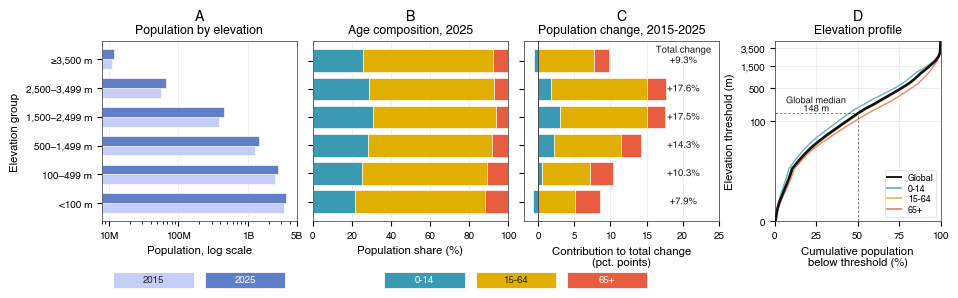

Figure 1 profile source data: data/fact_population_by_integer_elevation_age_sex_2015_2025.parquet
Figure 1 global median elevation: 148 m
Figure 1 profile y-axis labels: 0, 100, 500, 1,500, 3,500 m


In [4]:
from matplotlib.ticker import FixedLocator, FuncFormatter, NullLocator
import matplotlib.patheffects as pe

fig1_age_contrib = pd.read_csv(TAB / 'fig01_age_contribution_values.csv')
contrib_pivot = (
    fig1_age_contrib
    .pivot(index='elevation_group', columns='age_group', values='contribution_to_total_growth_pp')
    .reindex(index=ELEVATION_ORDER, columns=['0-14', '15-64', '65+'])
)
contrib_check = (
    fig1_age_contrib.groupby('elevation_group', as_index=False)
    .agg(sum_contribution_pp=('contribution_to_total_growth_pp', 'sum'), total_growth_percent=('total_growth_percent', 'first'))
)
contrib_check['difference_pp'] = contrib_check['sum_contribution_pp'] - contrib_check['total_growth_percent']
assert np.allclose(contrib_check['difference_pp'], 0, atol=1e-8), 'Figure 1C age contributions do not sum to total growth.'

FIG1_YEAR_COLORS = {'2015': '#C6CDF7', '2025': '#5F7FC8'}
FIG1_AGE_COLORS = {'0-14': '#3B9AB2', '15-64': '#E1AF00', '65+': '#E85D3F'}
FIG1_PROFILE_LINE_COLOR = '#111111'
FIG1_GRID_COLOR = '0.90'
FIG1_AXIS_COLOR = '0.25'
FIG1_SOURCE_PROFILE_DATA = DATA / 'fact_population_by_integer_elevation_age_sex_2015_2025.parquet'
FIG1_PROFILE_YEAR = 2025
FIG1_MIN_ELEV_M = 0
FIG1_MAX_ELEV_M = 8000
FIG1_PROFILE_YMAX_M = 5000
FIG1_SYMLINTHRESH_M = 10
FIG1_PROFILE_Y_LABEL_TICKS_M = [0, 100, 500, 1500, 3500]
FIG1_AGE_PROFILE_GROUPS = [
    ('0-14', ['young_0_14']),
    ('15-64', ['working_age_15_64']),
    ('65+', ['old_age_65_plus', 'older_65_plus']),
]
FIG1_FIGURE_WIDTH_IN = PNAS_FULL_WIDTH_IN * 1.55
FIG1_FIGURE_HEIGHT_IN = 3.75
FIG1_PANEL_WIDTH_IN = 1.95
FIG1_PANEL_HEIGHT_IN = 1.80
FIG1_PROFILE_WIDTH_IN = FIG1_PANEL_WIDTH_IN * 0.85
FIG1_PANEL_BOTTOM_IN = 1.25
FIG1_PANEL_A_LEFT_IN = 0.88
FIG1_ABC_GAP_IN = 0.16
FIG1_CD_GAP_IN = 0.56
FIG1_TITLE_SIZE = 8.9
FIG1_LABEL_SIZE = 8.2
FIG1_TICK_SIZE = 7.2
FIG1_PANEL_LABEL_SIZE = 10.2
FIG1_LEGEND_TEXT_SIZE = 7.0
FIG1_ANNOTATION_SIZE = 6.9
FIG1_PROFILE_LEGEND_SIZE = 6.4
FIG1_MEDIAN_TEXT_SIZE = 6.7


def fig1_fmt_elevation(x, _pos=None):
    return f'{x:,.0f}'


def fig1_build_cdf(df):
    cdf = (
        df.groupby('elevation_threshold_m', as_index=False)['population_count']
        .sum()
        .rename(columns={'elevation_threshold_m': 'elevation_m'})
        .sort_values('elevation_m')
    )
    all_thresholds = pd.DataFrame({'elevation_m': np.arange(FIG1_MIN_ELEV_M, FIG1_MAX_ELEV_M + 1)})
    cdf = all_thresholds.merge(cdf, on='elevation_m', how='left').fillna({'population_count': 0.0})
    cdf['cum_pop'] = cdf['population_count'].cumsum()
    total_pop = float(cdf['population_count'].sum())
    cdf['cum_frac_percent'] = cdf['cum_pop'] / total_pop * 100
    return cdf


def fig1_load_global_profile():
    if not FIG1_SOURCE_PROFILE_DATA.exists():
        raise FileNotFoundError(f'Missing profile source data: {FIG1_SOURCE_PROFILE_DATA.relative_to(ROOT)}')
    df = pd.read_parquet(
        FIG1_SOURCE_PROFILE_DATA,
        columns=['year', 'geography_level', 'continent', 'elevation_m', 'broad_age_group', 'population_count'],
        filters=[('year', '=', FIG1_PROFILE_YEAR), ('geography_level', '=', 'global'), ('continent', '=', 'Global')],
    )
    df['elevation_m'] = pd.to_numeric(df['elevation_m'], errors='coerce')
    df['population_count'] = pd.to_numeric(df['population_count'], errors='coerce').fillna(0)
    df = df.dropna(subset=['elevation_m']).copy()
    df['elevation_threshold_m'] = df['elevation_m'].clip(lower=FIG1_MIN_ELEV_M, upper=FIG1_MAX_ELEV_M).round().astype(int)

    cdf = fig1_build_cdf(df)
    age_cdfs = {
        label: fig1_build_cdf(df[df['broad_age_group'].isin(source_groups)])
        for label, source_groups in FIG1_AGE_PROFILE_GROUPS
    }
    total_pop = float(cdf['population_count'].sum())
    median_elevation = float(cdf.loc[cdf['cum_pop'].ge(total_pop / 2), 'elevation_m'].iloc[0])
    return cdf, age_cdfs, median_elevation


def legend_text_color(hex_color, label=None):
    if label in {'2025', '0-14', '65+'}:
        return 'white'
    rgb = mpl.colors.to_rgb(hex_color)
    luminance = 0.2126 * rgb[0] + 0.7152 * rgb[1] + 0.0722 * rgb[2]
    return 'white' if luminance < 0.52 else '0.12'


def draw_box_legend(fig, *, items, center_x, y0, box_width=0.074, box_height=0.044, gap=0.010):
    total_width = len(items) * box_width + (len(items) - 1) * gap
    x0 = center_x - total_width / 2
    for i, (label, color) in enumerate(items):
        x = x0 + i * (box_width + gap)
        rect = mpl.patches.Rectangle(
            (x, y0),
            box_width,
            box_height,
            transform=fig.transFigure,
            facecolor=color,
            edgecolor='white',
            linewidth=0.55,
            clip_on=False,
        )
        fig.add_artist(rect)
        fig.text(
            x + box_width / 2,
            y0 + box_height / 2,
            label,
            ha='center',
            va='center',
            fontsize=FIG1_LEGEND_TEXT_SIZE,
            color=legend_text_color(color, label),
            fontweight='bold' if label in {'2025', '0-14', '65+'} else 'normal',
        )


def panel_label_centered(ax, label):
    ax.text(
        0.5,
        1.1,
        label,
        transform=ax.transAxes,
        fontweight='bold',
        va='bottom',
        ha='center',
        fontsize=FIG1_PANEL_LABEL_SIZE,
    )


def add_axis_by_inches(fig, *, left, bottom, width, height):
    fig_width, fig_height = fig.get_size_inches()
    return fig.add_axes([left / fig_width, bottom / fig_height, width / fig_width, height / fig_height])


def draw_population_panel(ax, fig, y, labels):
    h = 0.34
    xmin = 0.008
    ax.barh(
        y - h / 2,
        main_fig01_data['population_2015_billions'] - xmin,
        left=xmin,
        height=h,
        color=FIG1_YEAR_COLORS['2015'],
        edgecolor='white',
        linewidth=0.45,
    )
    ax.barh(
        y + h / 2,
        main_fig01_data['population_2025_billions'] - xmin,
        left=xmin,
        height=h,
        color=FIG1_YEAR_COLORS['2025'],
        edgecolor='white',
        linewidth=0.45,
    )
    ax.set_xscale('log')
    ax.set_xlim(xmin, 5.0)
    ax.set_xticks([0.01, 0.1, 1, 5])
    ax.set_xticklabels(['10M', '100M', '1B', '5B'])
    ax.set_yticks(y, labels)
    ax.set_xlabel('Population, log scale', fontsize=FIG1_LABEL_SIZE)
    ax.set_ylabel('Elevation group', fontsize=FIG1_LABEL_SIZE)
    ax.set_title('Population by elevation', fontsize=FIG1_TITLE_SIZE)
    ax.tick_params(axis='both', labelsize=FIG1_TICK_SIZE)
    style_axes(ax, grid_axis='x')
    panel_label_centered(ax, 'A')
    draw_box_legend(
        fig,
        items=[('2015', FIG1_YEAR_COLORS['2015']), ('2025', FIG1_YEAR_COLORS['2025'])],
        center_x=(ax.get_position().x0 + ax.get_position().x1) / 2,
        y0=0.155,
    )


def draw_age_composition_panel(ax, y):
    left = np.zeros(len(main_fig01_data))
    for col, lab in [('youth_share_percent', '0-14'), ('working_age_share_percent', '15-64'), ('old_age_share_percent', '65+')]:
        vals = main_fig01_data[col].to_numpy()
        ax.barh(y, vals, left=left, color=FIG1_AGE_COLORS[lab], edgecolor='white', linewidth=0.45)
        left += vals
    ax.set_xlim(0, 100)
    ax.set_yticks(y)
    ax.tick_params(axis='y', labelleft=False)
    ax.set_xlabel('Population share (%)', fontsize=FIG1_LABEL_SIZE)
    ax.set_title('Age composition, 2025', fontsize=FIG1_TITLE_SIZE)
    ax.tick_params(axis='both', labelsize=FIG1_TICK_SIZE)
    style_axes(ax, grid_axis='x')
    panel_label_centered(ax, 'B')


def draw_growth_panel(ax, fig, y, legend_center_x):
    pos_left = np.zeros(len(contrib_pivot))
    neg_left = np.zeros(len(contrib_pivot))
    for age in ['0-14', '15-64', '65+']:
        vals = contrib_pivot[age].to_numpy()
        left = np.where(vals >= 0, pos_left, neg_left)
        ax.barh(y, vals, left=left, color=FIG1_AGE_COLORS[age], edgecolor='white', linewidth=0.45)
        pos_left += np.where(vals > 0, vals, 0)
        neg_left += np.where(vals < 0, vals, 0)
    ax.axvline(0, color='0.28', linewidth=0.7)
    growth_label_x = 20.1
    ax.set_xlim(min(-2, np.nanmin(neg_left) - 0.5), 25.0)
    ax.set_yticks(y)
    ax.tick_params(axis='y', labelleft=False)
    ax.text(
        growth_label_x,
        0.975,
        'Total change',
        transform=ax.get_xaxis_transform(),
        ha='center',
        va='top',
        fontsize=FIG1_ANNOTATION_SIZE,
        fontweight='bold',
        color='0.12',
        clip_on=False,
        path_effects=[pe.withStroke(linewidth=1.1, foreground='white')],
    )
    for i, elev in enumerate(contrib_pivot.index):
        total_growth = fig1_age_contrib.loc[fig1_age_contrib['elevation_group'].eq(elev), 'total_growth_percent'].iloc[0]
        ax.text(
            growth_label_x,
            y[i],
            f'{total_growth:+.1f}%',
            va='center',
            ha='center',
            fontsize=FIG1_ANNOTATION_SIZE,
            color='0.12',
            path_effects=[pe.withStroke(linewidth=1.2, foreground='white')],
        )
    ax.set_xlabel('Contribution to total change\n(pct. points)', fontsize=FIG1_LABEL_SIZE)
    ax.set_title('Population change, 2015-2025', fontsize=FIG1_TITLE_SIZE, linespacing=0.95)
    ax.tick_params(axis='both', labelsize=FIG1_TICK_SIZE)
    style_axes(ax, grid_axis='x')
    panel_label_centered(ax, 'C')
    draw_box_legend(
        fig,
        items=[(a, FIG1_AGE_COLORS[a]) for a in ['0-14', '15-64', '65+']],
        center_x=legend_center_x,
        y0=0.155,
    )


def draw_profile_panel(ax, cdf, age_cdfs, median_elevation):
    median_x = 50.0
    ax.set_xlim(0, 100)
    ax.set_xticks([0, 25, 50, 75, 100])
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_ylim(FIG1_MIN_ELEV_M, FIG1_PROFILE_YMAX_M)
    ax.set_yscale('symlog', linthresh=FIG1_SYMLINTHRESH_M)
    ax.yaxis.set_major_locator(FixedLocator(FIG1_PROFILE_Y_LABEL_TICKS_M))
    ax.yaxis.set_major_formatter(FuncFormatter(fig1_fmt_elevation))
    ax.yaxis.set_minor_locator(NullLocator())
    ax.grid(True, which='major', axis='x', linestyle='-', linewidth=0.45, color=FIG1_GRID_COLOR, zorder=1)
    for guide_m in FIG1_PROFILE_Y_LABEL_TICKS_M:
        ax.axhline(guide_m, color=FIG1_GRID_COLOR, linewidth=0.45, zorder=1)
    for age_label, age_cdf in age_cdfs.items():
        ax.plot(
            age_cdf['cum_frac_percent'],
            age_cdf['elevation_m'],
            color=FIG1_AGE_COLORS[age_label],
            linewidth=1.05,
            alpha=0.72,
            label=age_label,
            zorder=3,
        )
    ax.plot(
        cdf['cum_frac_percent'],
        cdf['elevation_m'],
        color=FIG1_PROFILE_LINE_COLOR,
        linewidth=1.9,
        alpha=1.0,
        label='Global',
        zorder=5,
    )
    guide_style = (0, (2.4, 2.0))
    ax.plot([0, median_x], [median_elevation, median_elevation], color='0.18', linewidth=0.7, alpha=0.62, linestyle=guide_style, zorder=6)
    ax.plot([median_x, median_x], [FIG1_MIN_ELEV_M, median_elevation], color='0.18', linewidth=0.7, alpha=0.62, linestyle=guide_style, zorder=6)
    ax.text(
        median_x * 0.50,
        median_elevation,
        f'Global median\n{median_elevation:.0f} m',
        ha='center',
        va='bottom',
        fontsize=FIG1_MEDIAN_TEXT_SIZE,
        linespacing=0.88,
        color='0.12',
        path_effects=[pe.withStroke(linewidth=0.9, foreground='white')],
        zorder=8,
    )
    handles, legend_labels = ax.get_legend_handles_labels()
    order = [legend_labels.index(label) for label in ['Global', '0-14', '15-64', '65+'] if label in legend_labels]
    legend = ax.legend(
        [handles[i] for i in order],
        [legend_labels[i] for i in order],
        loc='lower right',
        fontsize=FIG1_PROFILE_LEGEND_SIZE,
        frameon=True,
        framealpha=0.92,
        edgecolor='0.82',
        handlelength=1.5,
        borderpad=0.28,
        labelspacing=0.20,
    )
    legend.get_frame().set_linewidth(0.45)
    for line in legend.get_lines():
        line.set_linewidth(1.35)
    ax.set_xlabel('Cumulative population\nbelow threshold (%)', fontsize=FIG1_LABEL_SIZE)
    ax.set_ylabel('Elevation threshold (m)', fontsize=FIG1_LABEL_SIZE)
    ax.set_title('Elevation profile', fontsize=FIG1_TITLE_SIZE)
    ax.tick_params(axis='both', labelsize=FIG1_TICK_SIZE)
    style_axes(ax, grid_axis=None)
    panel_label_centered(ax, 'D')


cdf, age_cdfs, median_elevation = fig1_load_global_profile()
y = np.arange(len(main_fig01_data))
labels = [ELEVATION_LABELS[e] for e in main_fig01_data['elevation_group'].astype(str)]

fig = plt.figure(figsize=(FIG1_FIGURE_WIDTH_IN, FIG1_FIGURE_HEIGHT_IN))
ax_population = add_axis_by_inches(
    fig,
    left=FIG1_PANEL_A_LEFT_IN,
    bottom=FIG1_PANEL_BOTTOM_IN,
    width=FIG1_PANEL_WIDTH_IN,
    height=FIG1_PANEL_HEIGHT_IN,
)
ax_age = add_axis_by_inches(
    fig,
    left=FIG1_PANEL_A_LEFT_IN + FIG1_PANEL_WIDTH_IN + FIG1_ABC_GAP_IN,
    bottom=FIG1_PANEL_BOTTOM_IN,
    width=FIG1_PANEL_WIDTH_IN,
    height=FIG1_PANEL_HEIGHT_IN,
)
ax_growth = add_axis_by_inches(
    fig,
    left=FIG1_PANEL_A_LEFT_IN + 2 * (FIG1_PANEL_WIDTH_IN + FIG1_ABC_GAP_IN),
    bottom=FIG1_PANEL_BOTTOM_IN,
    width=FIG1_PANEL_WIDTH_IN,
    height=FIG1_PANEL_HEIGHT_IN,
)
ax_profile = add_axis_by_inches(
    fig,
    left=FIG1_PANEL_A_LEFT_IN + 3 * FIG1_PANEL_WIDTH_IN + 2 * FIG1_ABC_GAP_IN + FIG1_CD_GAP_IN,
    bottom=FIG1_PANEL_BOTTOM_IN,
    width=FIG1_PROFILE_WIDTH_IN,
    height=FIG1_PANEL_HEIGHT_IN,
)

draw_population_panel(ax_population, fig, y, labels)
draw_age_composition_panel(ax_age, y)
age_growth_legend_center = (ax_age.get_position().x0 + ax_growth.get_position().x1) / 2
draw_growth_panel(ax_growth, fig, y, age_growth_legend_center)
draw_profile_panel(ax_profile, cdf, age_cdfs, median_elevation)

savefig('fig1_hypsographic_summary', fig)
plt.show()

print(f'Figure 1 profile source data: {FIG1_SOURCE_PROFILE_DATA.relative_to(ROOT)}')
print(f'Figure 1 global median elevation: {median_elevation:.0f} m')
print('Figure 1 profile y-axis labels: ' + ', '.join(f'{tick:,}' for tick in FIG1_PROFILE_Y_LABEL_TICKS_M) + ' m')


## Main Figure 2

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


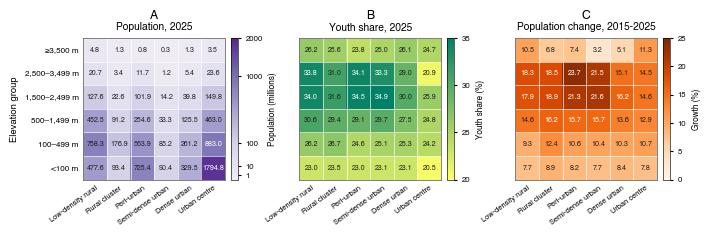

In [5]:
matrix_elev_order = list(reversed(ELEVATION_ORDER))
pop_mat = main_fig02_static.pivot(index='elevation_group', columns='settlement_class', values='population_2025_millions').reindex(index=matrix_elev_order, columns=SETTLEMENT_ORDER)
youth_mat = main_fig02_static.pivot(index='elevation_group', columns='settlement_class', values='youth_share_percent').reindex(index=matrix_elev_order, columns=SETTLEMENT_ORDER)
growth_mat = main_fig02_static.pivot(index='elevation_group', columns='settlement_class', values='growth_static2025_percent').reindex(index=matrix_elev_order, columns=SETTLEMENT_ORDER)

def annotate_matrix(ax, data, cmap, norm, fmt='{:.1f}', fontsize=5.1):
    arr = np.asarray(data, dtype=float)
    cmap_obj = mpl.colormaps[cmap] if isinstance(cmap, str) else cmap
    if not np.isfinite(arr).any():
        return
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            val = arr[i, j]
            if np.isfinite(val):
                r, g, b, _ = cmap_obj(norm(val))
                luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
                color = 'white' if luminance < 0.50 else '0.12'
                ax.text(j, i, fmt.format(val), ha='center', va='center', fontsize=fontsize, color=color, fontweight='normal')

# Sequential growth scale: 0 to observed max, no clipping/thresholding.
population_cmap = mpl.colors.LinearSegmentedColormap.from_list(
    'population_lavender_purple',
    ['#F1EEF6', '#D7D4EA', '#A6A1CF', '#756BB1', '#54278F'],
)
growth_cmap = mpl.cm.Oranges.copy()
growth_norm = mpl.colors.Normalize(vmin=0, vmax=25)
growth_ticks = [0, 5, 10, 15, 20, 25]

fig, axes = plt.subplots(1, 3, figsize=(PNAS_FULL_WIDTH_IN, 2.95), sharey=True)
fig.subplots_adjust(left=0.105, right=0.985, top=0.82, bottom=0.34, wspace=0.17)

panels = [
    (
        axes[0],
        pop_mat,
        'Population, 2025',
        population_cmap,
        mpl.colors.PowerNorm(
            gamma=0.45,
            vmin=0,
            vmax=2000
        ),
        '{:.1f}',
        'Population (millions)',
        [1, 10, 100, 1000, 2000],
        'neither',
        False
    ),
    (
        axes[1],
        youth_mat,
        'Youth share, 2025',
        'summer_r',
        mpl.colors.Normalize(vmin=20, vmax=35),
        '{:.1f}',
        'Youth share (%)',
        [20, 25, 30, 35],
        'neither',
        False
    ),
    (
        axes[2],
        growth_mat,
        'Population change, 2015-2025',
        growth_cmap,
        growth_norm,
        '{:.1f}',
        'Growth (%)',
        growth_ticks,
        'neither',
        False
    ),
]

for idx, (ax, data, title, cmap, norm, fmt, cbar_label, ticks, extend, is_growth) in enumerate(panels):
    im = ax.imshow(data, cmap=cmap, norm=norm, aspect='equal')
    annotate_matrix(ax, data, cmap=cmap, norm=norm, fmt=fmt)

    ax.set_title(title)
    ax.set_xticks(
        np.arange(len(SETTLEMENT_ORDER)),
        SETTLEMENT_ORDER,
        rotation=36,
        ha='right',
        rotation_mode='anchor'
    )
    ax.set_yticks(np.arange(len(matrix_elev_order)), [ELEVATION_LABELS[e] for e in matrix_elev_order])
    ax.tick_params(axis='x', length=0, labelsize=5.4)
    ax.tick_params(axis='y', length=0, labelleft=(idx == 0), labelsize=5.8)
    ax.set_xticks(np.arange(-0.5, len(SETTLEMENT_ORDER), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(matrix_elev_order), 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=0.45)
    ax.tick_params(which='minor', bottom=False, left=False)

    for spine in ax.spines.values():
        spine.set_linewidth(0.55)
        spine.set_color('0.38')

    if idx == 0:
        ax.set_ylabel('Elevation group')

    cbar = fig.colorbar(im, ax=ax, fraction=0.050, pad=0.030, ticks=ticks, extend=extend)
    cbar.ax.tick_params(labelsize=5.6, length=2)
    cbar.outline.set_linewidth(0.45)
    cbar.set_label(cbar_label, fontsize=5.9)

    panel_label(ax, chr(ord('A') + idx))

savefig('fig2_elevation_settlement_stats', fig)
plt.show()


## Main Figure 3

Figure 3 maps 2015-2025 population change across inhabited highland elevation-zone polygons (1,500-3,500 m).


Primary input: /Users/f6z/Documents/projects/montana_state/hypsographic_demography/data/fig3_highland_change_polygons.geoparquet
Base/context input: /Users/f6z/Documents/projects/montana_state/hypsographic_demography/data/country_elevation_group_polygons.geoparquet
Elevation groups found: ['1500-2499m', '2500-3499m']
Saved outputs/tables/fig3_highland_change_map_data.csv
Boundary source for fig3_highland_change_map: Natural Earth
Saved outputs/figures/fig3_highland_change_map.png


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


Saved outputs/figures/fig3_highland_change_map.pdf
Saved outputs/figures/fig3_highland_change_map.svg

Diagnostics
- Inhabited-highland country-elevation strata: 193
- Shown above POP_THRESHOLD=100,000: 74
- Total 2025 population in mapped inhabited-highland strata: 521,967,274
- Total absolute change 2015–2025: 77,849,911
- Weighted mean percent growth: 17.53%
- Growth among inhabited-highland strata min/median/max: -33.69% / 11.80% / 85.22%
- Growth among shown strata min/median/max: -6.40% / 14.22% / 40.65%

Top 10 retained strata by absolute population change
iso3     country_name elevation_group  pop_total_2025  pop_total_change_2015_2025  pop_total_pct_change_2015_2025
 ETH         Ethiopia      1500-2499m    8.729309e+07                2.058252e+07                       30.853451
 KEN            Kenya      1500-2499m    2.965345e+07                5.385153e+06                       22.190079
 MEX           Mexico      1500-2499m    6.358091e+07                5.292473e+06       

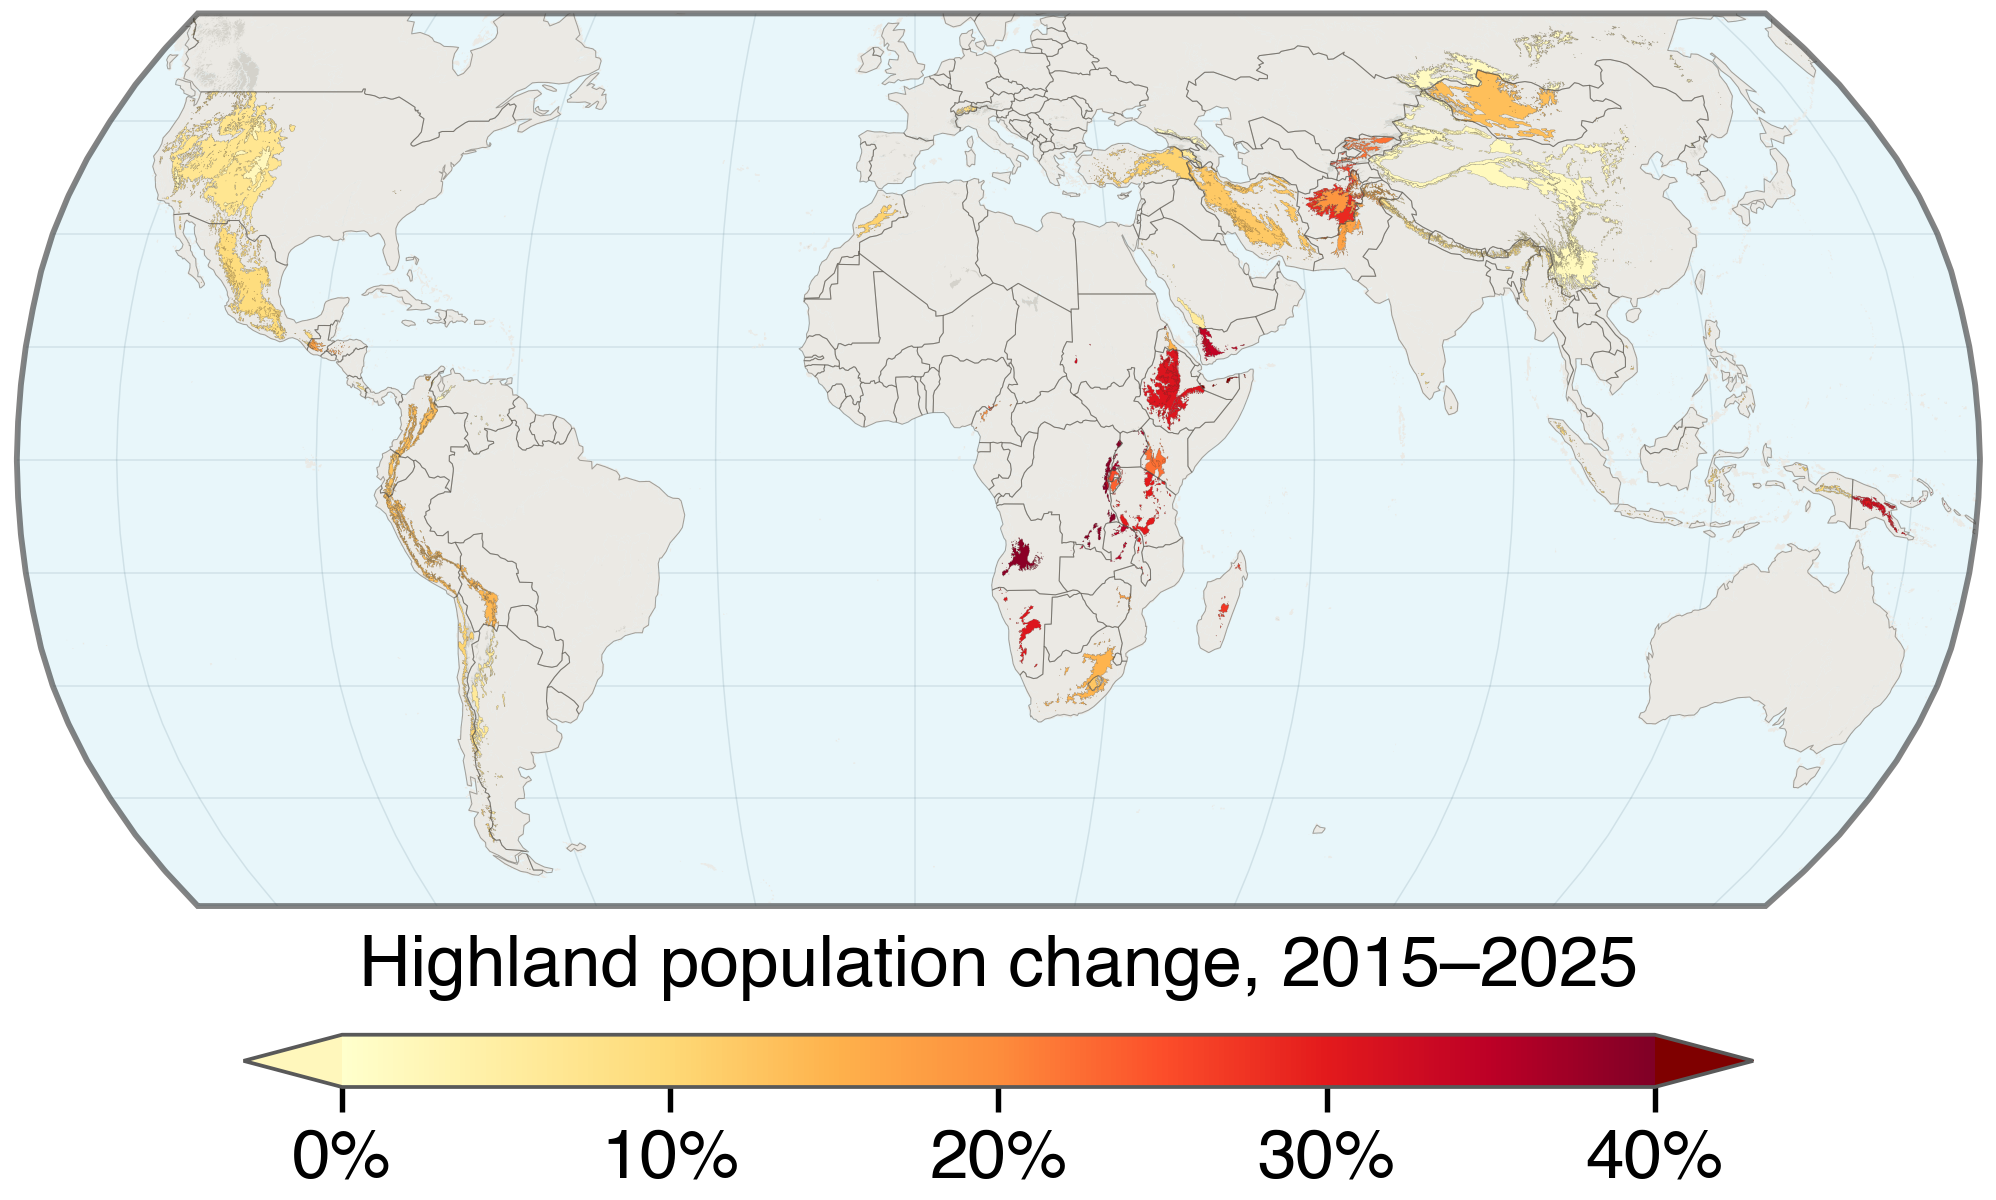

In [6]:
import runpy

runpy.run_path(str(ROOT / 'processing' / '06_plot_fig3_highland_change_map.py'), run_name='__main__')
display(Image.open(FIG / 'fig3_highland_change_map.png'))


## Key Manuscript Values

In [7]:
below100 = main_fig01_data.loc[main_fig01_data['elevation_group'].eq('<100 m'), 'population_total'].sum()
below500 = main_fig01_data.loc[main_fig01_data['elevation_group'].isin(['<100 m', '100-499 m']), 'population_total'].sum()
highland_1500_3500 = main_fig01_data.loc[main_fig01_data['elevation_group'].isin(['1500-2499 m', '2500-3499 m']), 'population_total'].sum()
highland_3500 = main_fig01_data.loc[main_fig01_data['elevation_group'].eq('>=3500 m'), 'population_total'].sum()
youth_below500 = main_fig01_data.loc[main_fig01_data['elevation_group'].isin(['<100 m', '100-499 m']), 'youth_population'].sum() / below500
youth_highland = main_fig01_data.loc[main_fig01_data['elevation_group'].isin(['1500-2499 m', '2500-3499 m']), 'youth_population'].sum() / highland_1500_3500
growth_below500 = main_fig01_data.loc[main_fig01_data['elevation_group'].isin(['<100 m', '100-499 m']), 'absolute_change'].sum() / main_fig01_data.loc[main_fig01_data['elevation_group'].isin(['<100 m', '100-499 m']), 'population_total_start'].sum()
growth_highland = main_fig01_data.loc[main_fig01_data['elevation_group'].isin(['1500-2499 m', '2500-3499 m']), 'absolute_change'].sum() / main_fig01_data.loc[main_fig01_data['elevation_group'].isin(['1500-2499 m', '2500-3499 m']), 'population_total_start'].sum()
strongest_pop = main_fig02_static.loc[main_fig02_static['pop_2025_static2025'].idxmax()]
strongest_youth = main_fig02_static.loc[main_fig02_static['youth_share_percent'].idxmax()]
strongest_growth = main_fig02_static.loc[main_fig02_static['growth_static2025_percent'].idxmax()]

integer_pop_2025 = pd.read_parquet(DATA / 'global_integer_elevation_age_sex_2015_2025.parquet')
if 'year' in integer_pop_2025.columns:
    integer_pop_2025 = integer_pop_2025[integer_pop_2025['year'].astype(int).eq(2025)].copy()
if 'geography_level' in integer_pop_2025.columns:
    integer_pop_2025 = integer_pop_2025[integer_pop_2025['geography_level'].astype(str).str.lower().eq('global')].copy()
if 'continent' in integer_pop_2025.columns:
    integer_pop_2025 = integer_pop_2025[integer_pop_2025['continent'].astype(str).str.lower().eq('global')].copy()
integer_pop_2025['elevation_m'] = pd.to_numeric(integer_pop_2025['elevation_m'], errors='coerce')
integer_pop_2025['population_count'] = pd.to_numeric(integer_pop_2025['population_count'], errors='coerce').fillna(0)
integer_pop_2025 = integer_pop_2025.dropna(subset=['elevation_m'])

elev_cdf = (
    integer_pop_2025.groupby('elevation_m', as_index=False)['population_count']
    .sum()
    .sort_values('elevation_m')
)
elev_cdf['cum_pop'] = elev_cdf['population_count'].cumsum()
population_weighted_median_elevation_2025 = float(
    elev_cdf.loc[elev_cdf['cum_pop'].ge(elev_cdf['population_count'].sum() / 2), 'elevation_m'].iloc[0]
)

below150 = integer_pop_2025.loc[integer_pop_2025['elevation_m'] <= 150, 'population_count'].sum()
below150_share = below150 / integer_pop_2025['population_count'].sum()
age_totals_2025 = integer_pop_2025.groupby('broad_age_group')['population_count'].sum()
age_below150_2025 = integer_pop_2025[integer_pop_2025['elevation_m'] <= 150].groupby('broad_age_group')['population_count'].sum()
below150_age_shares = age_below150_2025 / age_totals_2025

key_values = pd.DataFrame([
    {'metric': 'population below 500 m, 2025', 'value': below500, 'unit': 'people', 'source_table': 'data/dataset_s1_hypsographic_demography.csv', 'note': f'{bill(below500)}; {pct(below500 / global_pop_2025)} of global population'},
    {'metric': 'population below 100 m, 2025', 'value': below100, 'unit': 'people', 'source_table': 'data/dataset_s1_hypsographic_demography.csv', 'note': bill(below100)},
    {'metric': 'population below 150 m, 2025', 'value': below150, 'unit': 'people', 'source_table': 'data/global_integer_elevation_age_sex_2015_2025.parquet', 'note': f'{bill(below150)}; {pct(below150_share)} of global population'},
    {'metric': 'population-weighted median elevation, 2025', 'value': population_weighted_median_elevation_2025, 'unit': 'meters', 'source_table': 'data/global_integer_elevation_age_sex_2015_2025.parquet', 'note': f'{population_weighted_median_elevation_2025:.0f} m'},
    {'metric': 'share of young population below 150 m, 2025', 'value': below150_age_shares['young_0_14'], 'unit': 'share', 'source_table': 'outputs/tables/population_by_elevation_threshold_age_summary.csv', 'note': pct(below150_age_shares['young_0_14'])},
    {'metric': 'share of working-age population below 150 m, 2025', 'value': below150_age_shares['working_age_15_64'], 'unit': 'share', 'source_table': 'outputs/tables/population_by_elevation_threshold_age_summary.csv', 'note': pct(below150_age_shares['working_age_15_64'])},
    {'metric': 'share of old-age population below 150 m, 2025', 'value': below150_age_shares['old_age_65_plus'], 'unit': 'share', 'source_table': 'outputs/tables/population_by_elevation_threshold_age_summary.csv', 'note': pct(below150_age_shares['old_age_65_plus'])},
    {'metric': 'population 1500-3500 m, 2025', 'value': highland_1500_3500, 'unit': 'people', 'source_table': 'data/dataset_s1_hypsographic_demography.csv', 'note': bill(highland_1500_3500)},
    {'metric': 'youth share below 500 m, 2025', 'value': youth_below500, 'unit': 'share', 'source_table': 'data/dataset_s1_hypsographic_demography.csv', 'note': pct(youth_below500)},
    {'metric': 'youth share 1500-3500 m, 2025', 'value': youth_highland, 'unit': 'share', 'source_table': 'data/dataset_s1_hypsographic_demography.csv', 'note': pct(youth_highland)},
    {'metric': 'growth below 500 m, 2015-2025', 'value': growth_below500, 'unit': 'share', 'source_table': 'data/dataset_s1_hypsographic_demography.csv', 'note': pct(growth_below500)},
    {'metric': 'growth 1500-3500 m, 2015-2025', 'value': growth_highland, 'unit': 'share', 'source_table': 'data/dataset_s1_hypsographic_demography.csv', 'note': pct(growth_highland)},
    {'metric': 'population >=3500 m, 2025', 'value': highland_3500, 'unit': 'people', 'source_table': 'data/dataset_s1_hypsographic_demography.csv', 'note': f'{mill(highland_3500)}; {pct(highland_3500 / global_pop_2025)} of global population'},
    {'metric': 'strongest Figure 2 population cell', 'value': strongest_pop['pop_2025_static2025'], 'unit': 'people', 'source_table': 'data/dataset_s1_hypsographic_demography.csv', 'note': f'{strongest_pop.elevation_group} / {strongest_pop.settlement_class}'},
    {'metric': 'strongest Figure 2 youth-share cell', 'value': strongest_youth['youth_share'], 'unit': 'share', 'source_table': 'data/dataset_s1_hypsographic_demography.csv', 'note': f'{strongest_youth.elevation_group} / {strongest_youth.settlement_class}; {pct(strongest_youth.youth_share)}'},
    {'metric': 'strongest Figure 2 growth cell', 'value': strongest_growth['growth_static2025'], 'unit': 'share', 'source_table': 'data/dataset_s1_hypsographic_demography.csv', 'note': f'{strongest_growth.elevation_group} / {strongest_growth.settlement_class}; {pct(strongest_growth.growth_static2025)}'},
])
key_values.to_csv(TAB / 'key_values_for_manuscript.csv', index=False)
display(key_values)

print(f'Population below 500 m, 2025: {bill(below500)} ({pct(below500 / global_pop_2025)})')
print(f'Population below 100 m, 2025: {bill(below100)}')
print(f'Population below 150 m, 2025: {bill(below150)} ({pct(below150_share)})')
print(f'Population-weighted median elevation, 2025: {population_weighted_median_elevation_2025:.0f} m')
print('Share below 150 m by age group, 2025: ' + ', '.join([
    f'0-14: {pct(below150_age_shares["young_0_14"])}',
    f'15-64: {pct(below150_age_shares["working_age_15_64"])}',
    f'65+: {pct(below150_age_shares["old_age_65_plus"])}',
]))
print(f'Population 1,500-3,500 m, 2025: {bill(highland_1500_3500)}')
print(f'Youth share below 500 m, 2025: {pct(youth_below500)}')
print(f'Youth share 1,500-3,500 m, 2025: {pct(youth_highland)}')
print(f'Growth below 500 m, 2015-2025: {pct(growth_below500)}')
print(f'Growth 1,500-3,500 m, 2015-2025: {pct(growth_highland)}')
print(f'Population >=3,500 m, 2025: {mill(highland_3500)} ({pct(highland_3500 / global_pop_2025)})')


,metric,value,unit,source_table,note
0,"population below 500 m, 2025",6.242358e+09,people,data/dataset_s1_hypsographic_demography.csv,6.24 billion; 76.2% of global population
1,"population below 100 m, 2025",3.513598e+09,people,data/dataset_s1_hypsographic_demography.csv,3.51 billion
2,"population below 150 m, 2025",4.125621e+09,people,data/global_integer_elevation_age_sex_2015_202...,4.13 billion; 50.3% of global population
3,"population-weighted median elevation, 2025",1.480000e+02,meters,data/global_integer_elevation_age_sex_2015_202...,148 m
4,"share of young population below 150 m, 2025",4.490580e-01,share,outputs/tables/population_by_elevation_thresho...,44.9%
5,"share of working-age population below 150 m, 2025",5.139363e-01,share,outputs/tables/population_by_elevation_thresho...,51.4%
6,"share of old-age population below 150 m, 2025",5.655354e-01,share,outputs/tables/population_by_elevation_thresho...,56.6%
7,"population 1500-3500 m, 2025",5.219710e+08,people,data/dataset_s1_hypsographic_demography.csv,0.52 billion
8,"youth share below 500 m, 2025",2.323060e-01,share,data/dataset_s1_hypsographic_demography.csv,23.2%
9,"youth share 1500-3500 m, 2025",3.071246e-01,share,data/dataset_s1_hypsographic_demography.csv,30.7%


Population below 500 m, 2025: 6.24 billion (76.2%)
Population below 100 m, 2025: 3.51 billion
Population below 150 m, 2025: 4.13 billion (50.3%)
Population-weighted median elevation, 2025: 148 m
Share below 150 m by age group, 2025: 0-14: 44.9%, 15-64: 51.4%, 65+: 56.6%
Population 1,500-3,500 m, 2025: 0.52 billion
Youth share below 500 m, 2025: 23.2%
Youth share 1,500-3,500 m, 2025: 30.7%
Growth below 500 m, 2015-2025: 9.0%
Growth 1,500-3,500 m, 2015-2025: 17.5%
Population >=3,500 m, 2025: 12.1 million (0.1%)


## Robustness checks

The manuscript robustness summaries are stored in `data/dataset_s2_robustness_checks.csv`. They are generated from Dataset S1 by `processing/build_dataset_s2_robustness_checks.py` and do not reprocess the original gridded rasters. Dataset S2 is intended as a supporting dataset rather than an additional figure or SI table.
